In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.sparse as sp
import h5py
import anndata as ad

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn import preprocessing
from sklearn.metrics import f1_score
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
    classification_report,
)

seed = 123

In [2]:
data_dir = '../../data/frangieh'
adata = sc.read_h5ad(f'{data_dir}/rna.h5ad')

In [3]:
def preprocess(adata, min_genes, min_cells, total_cutoff, mt_cutoff):
    # mitochondrial genes, 'MT-' for human, 'Mt-' for mouse
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    # ribosomal genes
    adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
    # hemoglobin genes
    adata.var['hb'] = adata.var_names.str.contains('^HB[^(P)]')

    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], inplace=True, log1p=True)

    sc.pl.violin(
        adata,
        ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
        jitter=0.4,
        multi_panel=True,
    )
    
    # filter data using parameters
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    adata = adata[adata.obs.pct_counts_mt < mt_cutoff]
    adata = adata[adata.obs.total_counts < total_cutoff]
    adata = adata.copy()

    sc.pl.violin(
        adata,
        ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
        jitter=0.4,
        multi_panel=True,
    )

    sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')
    
    return adata



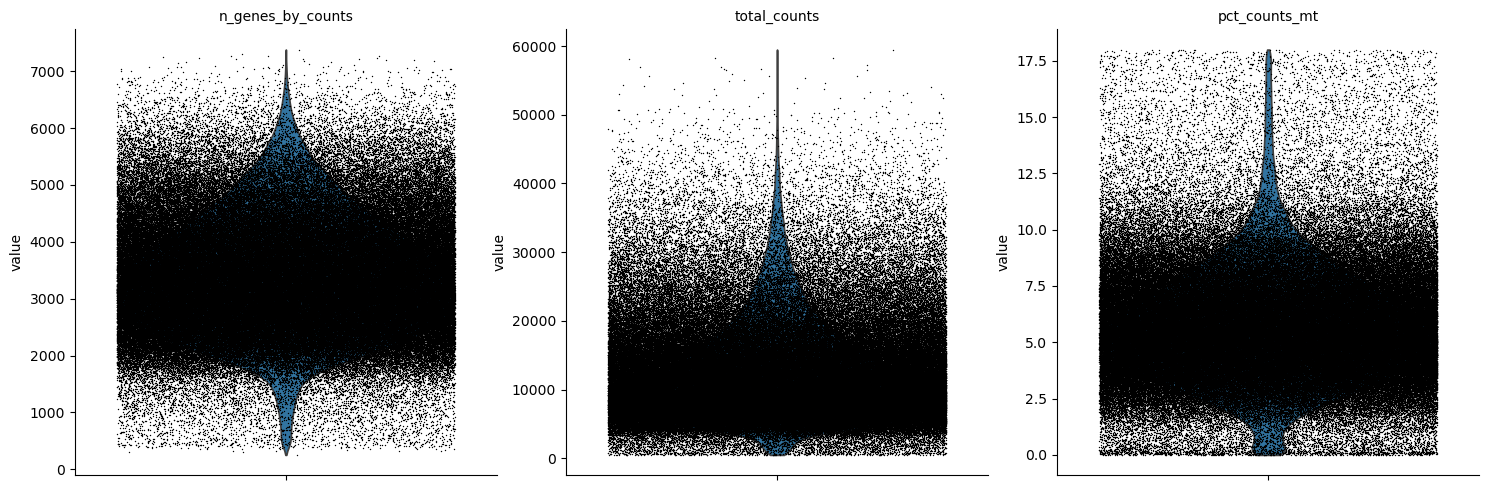

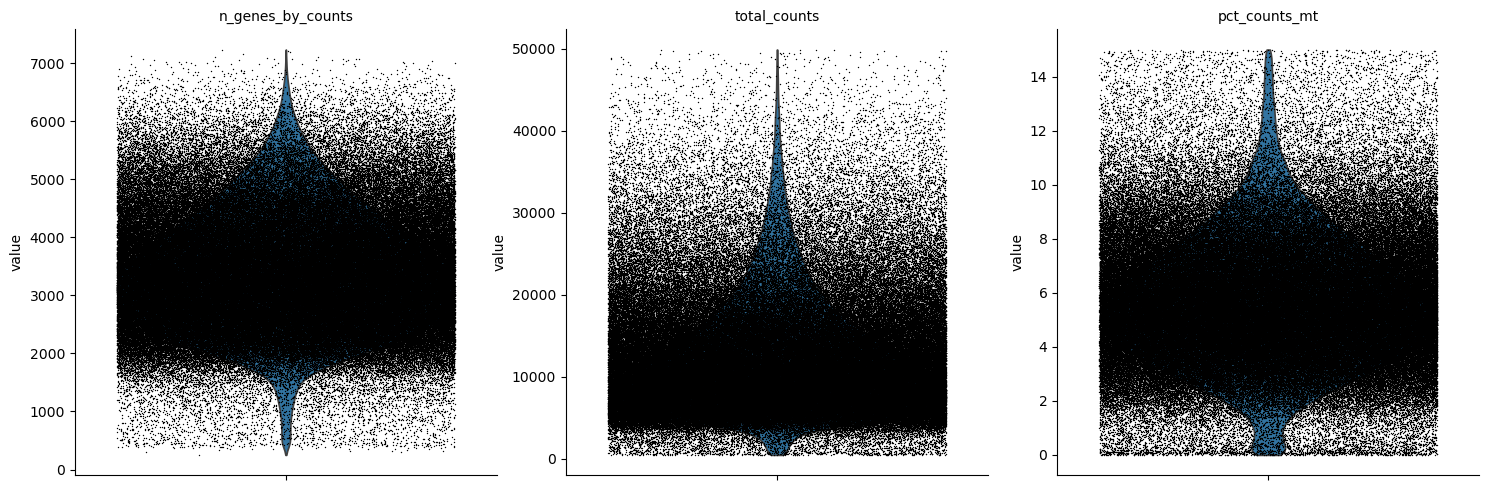

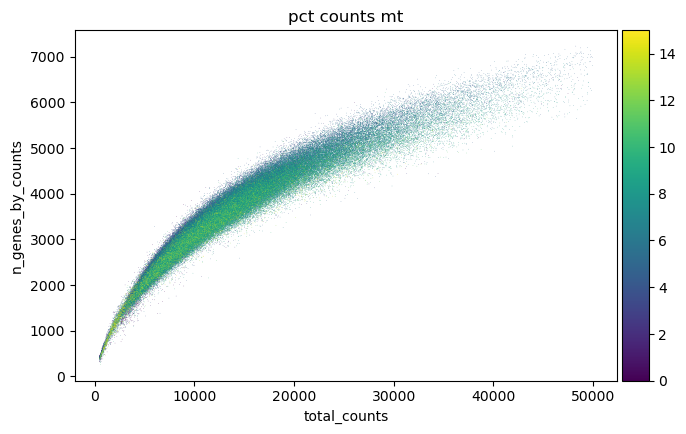

In [4]:
# Saving raw count data
adata.layers['raw'] = adata.X.copy()

adata = preprocess(adata, 200, 200, 50_000, 15) # values used in the original data: >200 genes, <18% mitochondrial genes, >200 cells

# normalize
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

-> More stringent filtering has been applied, mainly due to a large amount of cells with relatively few reads and a high percentage of mitochondrial reads. Therefore cells with more than 15% mitochondrial RNA and more than 50,000 total reads have been removed.

In [5]:
# Saving count data
# adata.layers['doublets'] = adata.X.copy()

# Scrublet doublet detection (might also use scdblfinder in R later)
# sc.pp.scrublet(adata)
# adata.obs['doublet'] = ['doublet' if element else 'singlet' for element in adata.obs.predicted_doublet.tolist()]
# adata = adata[adata.obs.doublet=='singlet']

scrublet doesn't run on this dataset in the VM. Try scdblfinder in R or try to run scrublet on culture conditions separately

## Split data into test and training set by *StratifiedKFold*

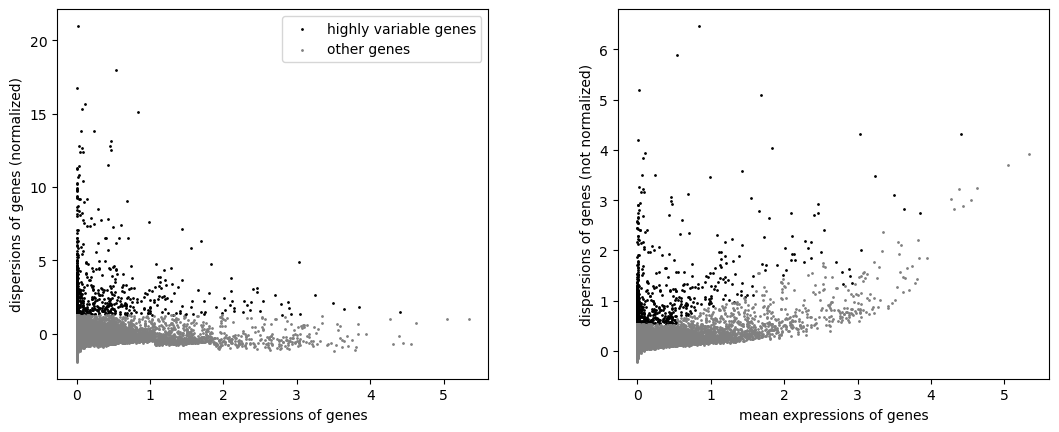

In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
sc.pl.highly_variable_genes(adata)
adata_hv = adata[:,adata.var['highly_variable']==True].copy()

In [7]:
sc.pp.pca(adata_hv, n_comps=50)
sc.pp.neighbors(adata_hv)
sc.tl.umap(adata_hv)

# Save data
adata_hv.write(f"{data_dir}/dataset_hv_tim.h5ad")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
#data_dir = '../data/frangieh'
#adata_hv = sc.read_h5ad(f"{data_dir}/dataset_hv_tim.h5ad")

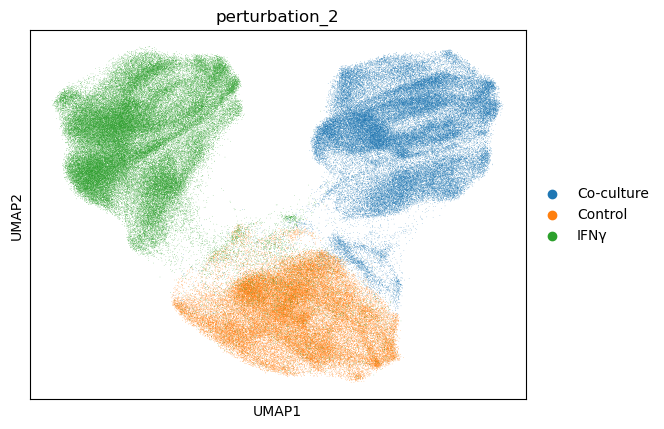

In [9]:
sc.pl.umap(adata_hv, color=['perturbation_2'])

In [10]:
le = preprocessing.LabelEncoder()
le.fit(adata_hv.obs['perturbation_2'])
adata_hv.obs['label'] = le.transform(adata_hv.obs['perturbation_2'])

In [11]:
pipe = make_pipeline(
    XGBClassifier(n_estimators=6, max_depth=6, learning_rate=0.05, objective='multi:softprob')
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

accuracy = cross_val_score(pipe, adata_hv.X, adata_hv.obs.label, cv=skf, scoring="balanced_accuracy", n_jobs=-1)
print(f"Balanced accuracy : {accuracy.mean():.3f} ± {accuracy.std():.3f}")

Balanced accuracy : 0.975 ± 0.001


# Calculate feature importance

Train a model using a stratified train and test split (1 fold, 20% test), evaluate its performance and compute feature importance

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


Balanced accuracy: 0.975


<Axes: >

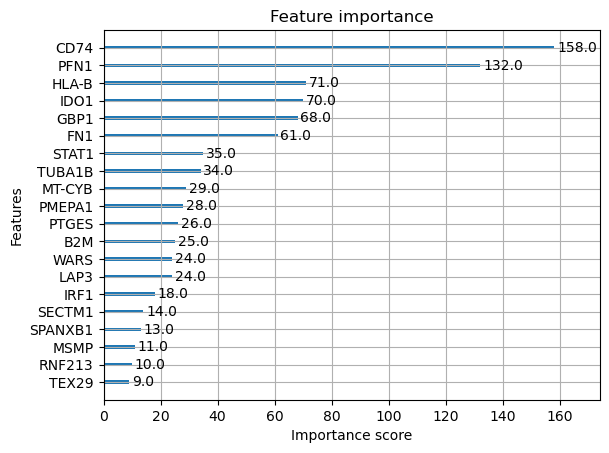

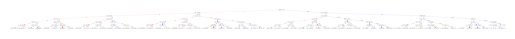

In [12]:
# evaluate feature importance

def fit_xgb(data, test_size, n_estimators, max_depth):
    X_train, X_test, y_train, y_test = train_test_split(data[:,data.var['highly_variable']==True].X, data.obs['label'], test_size=test_size,
                                                        stratify=data.obs.label, random_state=seed)

    X_train = pd.DataFrame.sparse.from_spmatrix(X_train, columns=data[:,data.var['highly_variable']==True].var_names)
    X_test = pd.DataFrame.sparse.from_spmatrix(X_test, columns=data[:,data.var['highly_variable']==True].var_names)
    
    # create model instance
    bst = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=0.05, objective='multi:softprob', importance_type='weight')
    # fit model
    bst.fit(X_train, y_train)
    # make predictions
    preds = bst.predict(X_test)

    score = round(
        balanced_accuracy_score(
            y_test, 
            preds, 
        ), 
        3
    )
    return(bst, score)
    
bst, b_acc = fit_xgb(adata_hv, .2, 6, 6)
print(f'Balanced accuracy: {b_acc}')
xgb.plot_importance(bst, max_num_features=20)
xgb.plot_tree(bst)

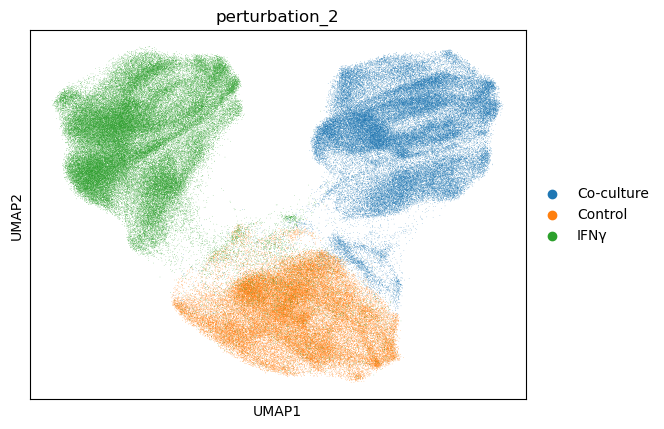

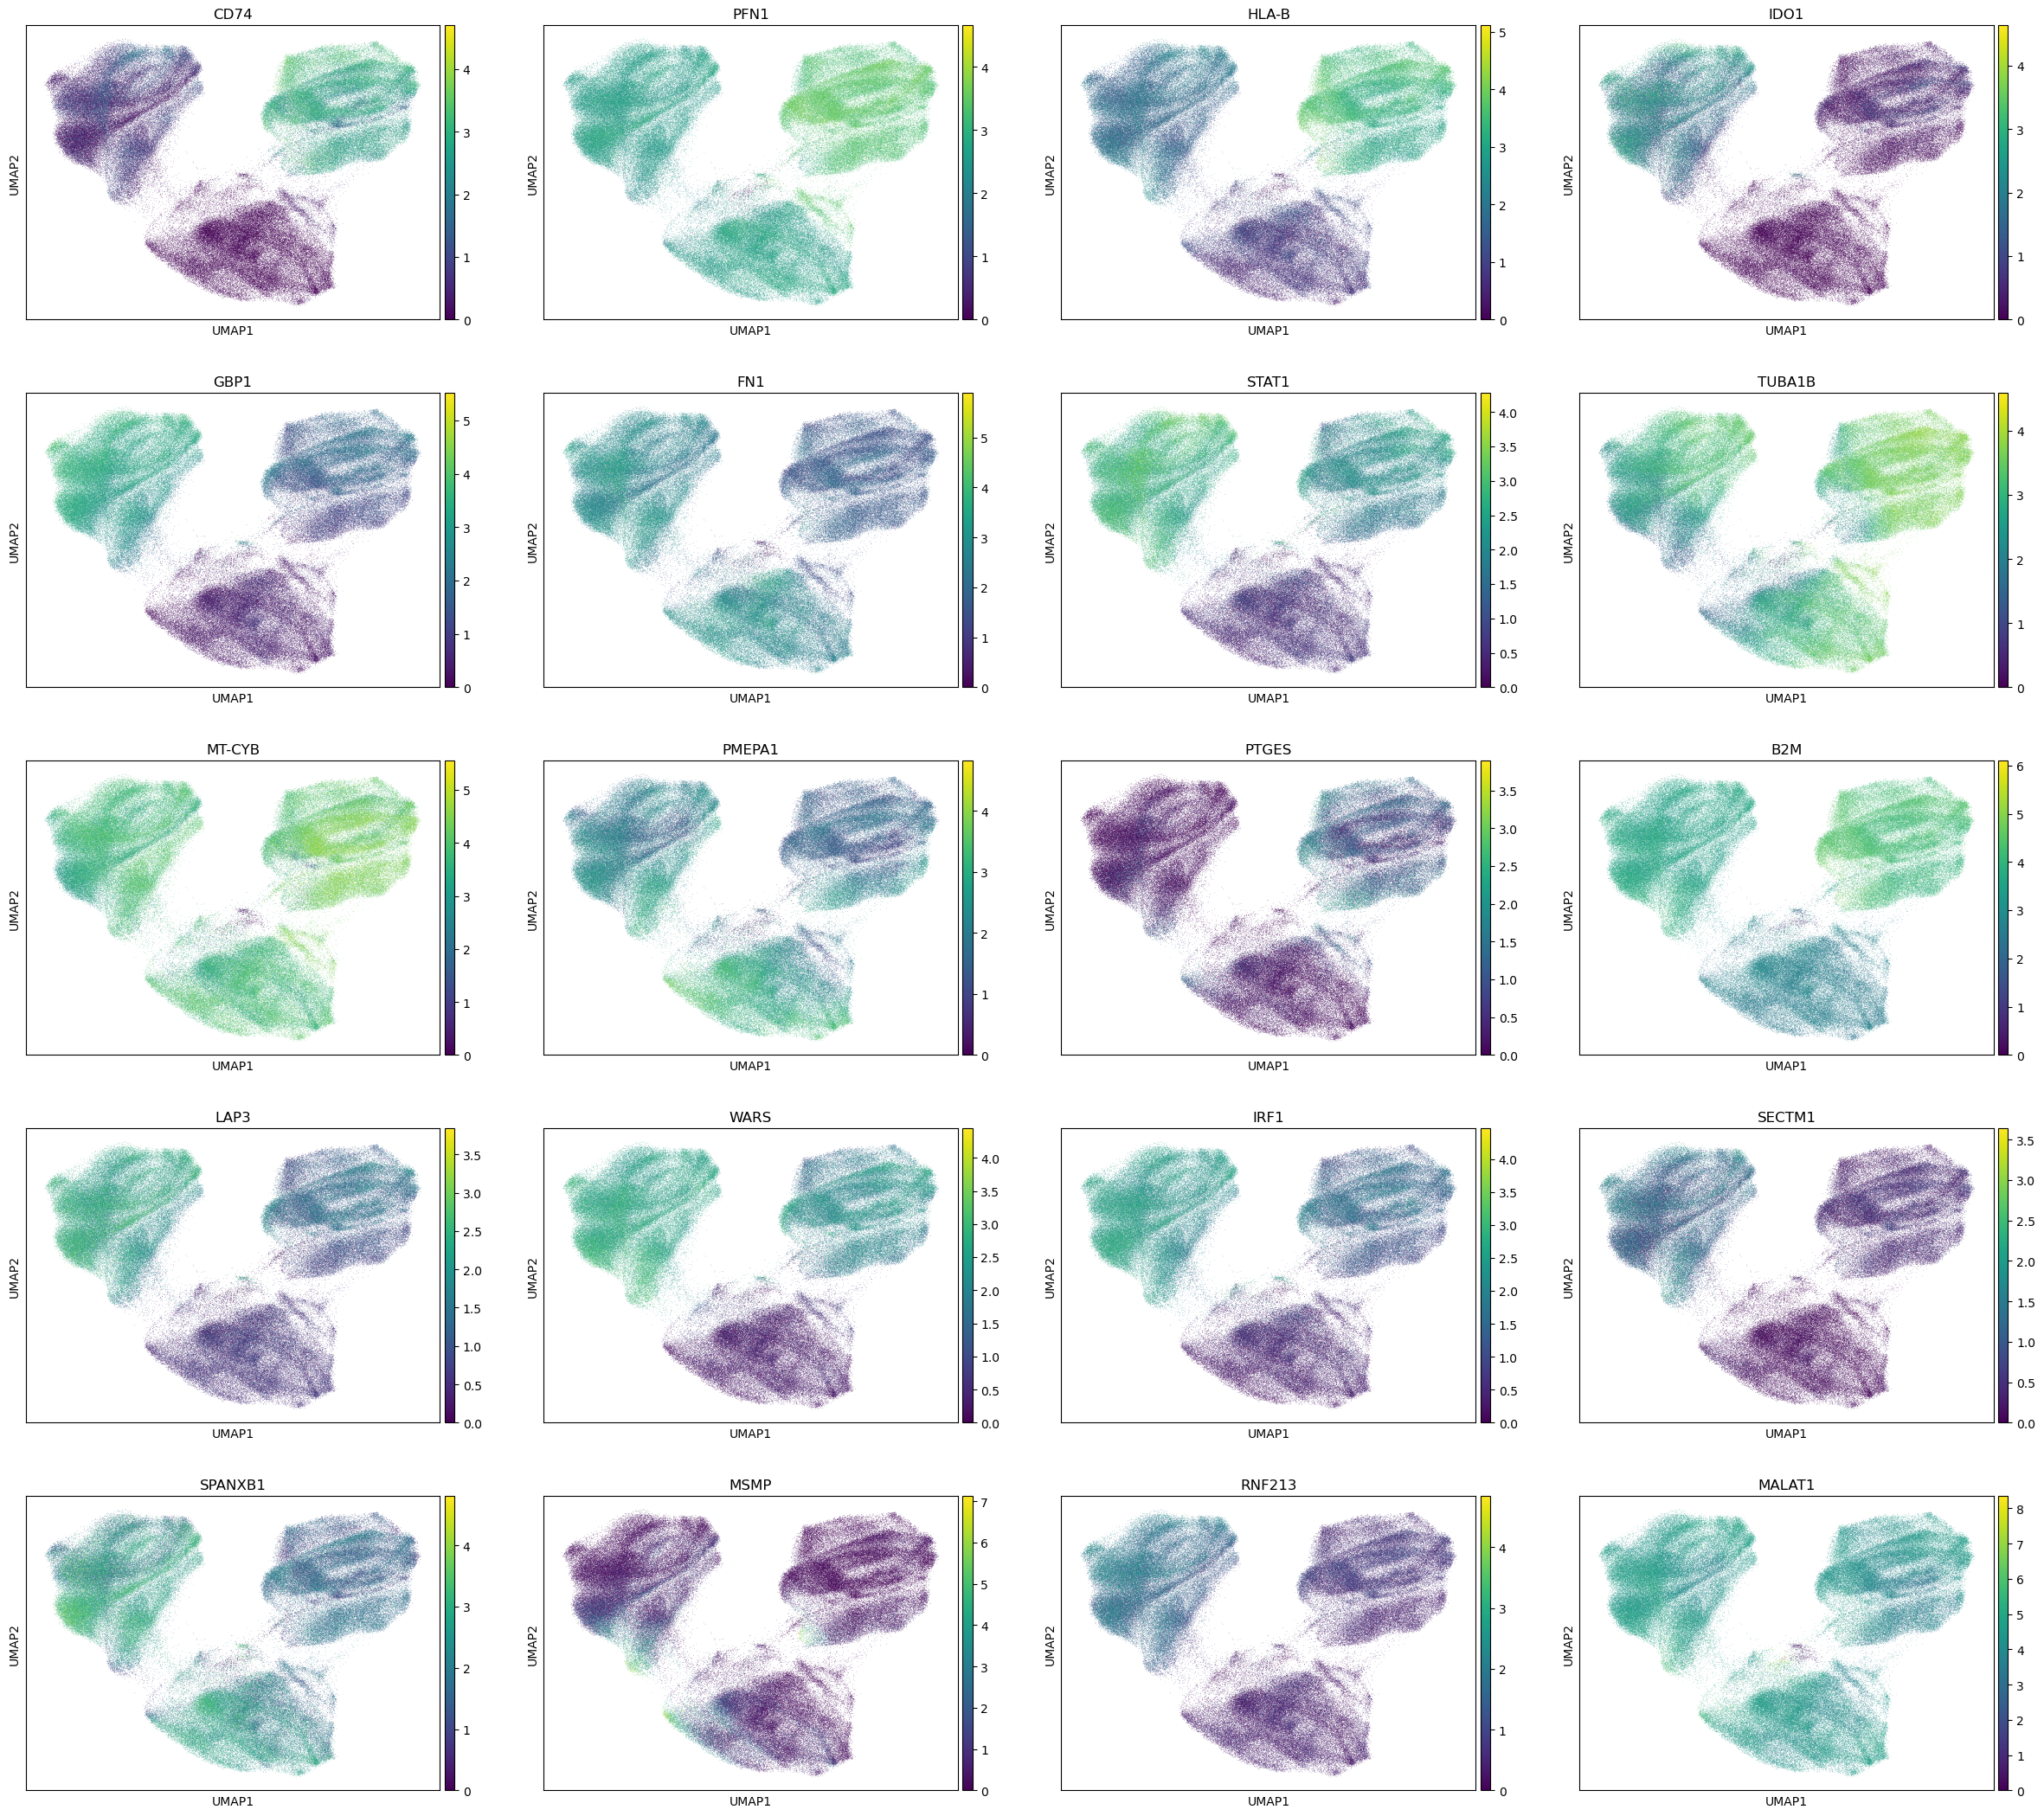

In [14]:
importances = pd.DataFrame(bst.feature_importances_, bst.feature_names_in_, columns=['importance'])

top_10_features = importances.sort_values('importance', ascending=False)[0:20].index
#for feature in top_10_features:
 #   _vals = adata[:,adata.var_names==feature].X
  #  _vals = _vals.toarray().flatten()
   # adata.obs[feature] = _vals>_vals.mean()

sc.pl.umap(adata_hv, color=['perturbation_2'])
sc.pl.umap(adata_hv, color=top_10_features.values.tolist())

The top 10 most important features show clear separation by cluster linked to the different treatment conditions. Based on the UMAPs, co-culture condition seems to be the condition with the most differences to the other conditions which are a little more similar. However, the UMAP shows that the model captures differences between treatment conditions rather well.